In [4]:
import sqlite3
import tkinter as tk
from tkinter import ttk, filedialog, messagebox
from PIL import Image, ImageTk
import pandas as pd
import os
import shutil
import datetime

# =============================================================================
# КОНФИГУРАЦИЯ И ПУТИ
# =============================================================================
BASE_DIR = os.getcwd()
RES_DIR = os.path.join(BASE_DIR, 'resources')
IMG_DIR = os.path.join(BASE_DIR, 'images')
DB_PATH = os.path.join(BASE_DIR, 'shop.db')
PLACEHOLDER = os.path.join(RES_DIR, 'picture.png')

if not os.path.exists(IMG_DIR):
    os.makedirs(IMG_DIR)

# =============================================================================
# МОДУЛЬ 1: МЕНЕДЖЕР БАЗЫ ДАННЫХ (3НФ)
# =============================================================================
class Database:
    def __init__(self):
        self.conn = sqlite3.connect(DB_PATH)
        self.conn.execute("PRAGMA foreign_keys = ON")
        self.c = self.conn.cursor()
        self._create_schema()
        self._import_data_from_excel()

    def _create_schema(self):
        # Справочники
        self.c.execute("CREATE TABLE IF NOT EXISTS Roles (RoleID INTEGER PRIMARY KEY, RoleName TEXT UNIQUE)")
        self.c.execute("CREATE TABLE IF NOT EXISTS Categories (CategoryID INTEGER PRIMARY KEY, CategoryName TEXT UNIQUE)")
        self.c.execute("CREATE TABLE IF NOT EXISTS Manufacturers (ManufacturerID INTEGER PRIMARY KEY, ManufacturerName TEXT UNIQUE)")
        self.c.execute("CREATE TABLE IF NOT EXISTS Suppliers (SupplierID INTEGER PRIMARY KEY, SupplierName TEXT UNIQUE)")
        self.c.execute("CREATE TABLE IF NOT EXISTS PickupPoints (PickupPointID INTEGER PRIMARY KEY, Address TEXT UNIQUE)")
        self.c.execute("CREATE TABLE IF NOT EXISTS OrderStatuses (StatusID INTEGER PRIMARY KEY, StatusName TEXT UNIQUE)")

        # Пользователи и товары
        self.c.execute("""CREATE TABLE IF NOT EXISTS Users (
            UserID INTEGER PRIMARY KEY AUTOINCREMENT,
            FullName TEXT NOT NULL,
            Login TEXT UNIQUE NOT NULL,
            Password TEXT NOT NULL,
            RoleID INTEGER NOT NULL,
            FOREIGN KEY (RoleID) REFERENCES Roles(RoleID)
        )""")
        self.c.execute("""CREATE TABLE IF NOT EXISTS Products (
            ProductID INTEGER PRIMARY KEY AUTOINCREMENT,
            Article TEXT UNIQUE NOT NULL,
            ProductName TEXT NOT NULL,
            Unit TEXT DEFAULT 'шт.',
            Price REAL NOT NULL CHECK(Price >= 0),
            SupplierID INTEGER NOT NULL,
            ManufacturerID INTEGER NOT NULL,
            CategoryID INTEGER NOT NULL,
            DiscountPercent REAL DEFAULT 0,
            StockQuantity INTEGER NOT NULL DEFAULT 0 CHECK(StockQuantity >= 0),
            Description TEXT,
            ImagePath TEXT,
            FOREIGN KEY (SupplierID) REFERENCES Suppliers(SupplierID),
            FOREIGN KEY (ManufacturerID) REFERENCES Manufacturers(ManufacturerID),
            FOREIGN KEY (CategoryID) REFERENCES Categories(CategoryID)
        )""")

        # Заказы и позиции
        self.c.execute("""CREATE TABLE IF NOT EXISTS Orders (
            OrderID INTEGER PRIMARY KEY AUTOINCREMENT,
            OrderNumber INTEGER UNIQUE NOT NULL,
            OrderDate TEXT NOT NULL,
            DeliveryDate TEXT,
            PickupPointID INTEGER NOT NULL,
            ClientID INTEGER NOT NULL,
            PickupCode TEXT,
            StatusID INTEGER NOT NULL DEFAULT 1,
            FOREIGN KEY (PickupPointID) REFERENCES PickupPoints(PickupPointID),
            FOREIGN KEY (ClientID) REFERENCES Users(UserID),
            FOREIGN KEY (StatusID) REFERENCES OrderStatuses(StatusID)
        )""")
        self.c.execute("""CREATE TABLE IF NOT EXISTS OrderItems (
            OrderItemID INTEGER PRIMARY KEY AUTOINCREMENT,
            OrderID INTEGER NOT NULL,
            ProductID INTEGER NOT NULL,
            Quantity INTEGER NOT NULL CHECK(Quantity > 0),
            FOREIGN KEY (OrderID) REFERENCES Orders(OrderID) ON DELETE CASCADE,
            FOREIGN KEY (ProductID) REFERENCES Products(ProductID)
        )""")
        self.conn.commit()

    def _import_data_from_excel(self):
        """Импорт данных из Excel при первом запуске (с нормализацией)"""
        try:
            # Роли
            roles = [(1, 'Гость'), (2, 'Авторизированный клиент'), (3, 'Менеджер'), (4, 'Администратор')]
            self.c.executemany("INSERT OR IGNORE INTO Roles VALUES (?, ?)", roles)

            # Статусы заказов
            statuses = [(1, 'Новый'), (2, 'Завершен')]
            self.c.executemany("INSERT OR IGNORE INTO OrderStatuses VALUES (?, ?)", statuses)

            # ======= ИСПРАВЛЕНИЕ ОШИБКИ FOREIGN KEY =======
            self.c.execute("INSERT OR IGNORE INTO Suppliers (SupplierID, SupplierName) VALUES (1, 'Основной поставщик')")
            self.c.execute("INSERT OR IGNORE INTO Manufacturers (ManufacturerID, ManufacturerName) VALUES (1, 'Основной производитель')")
            self.c.execute("INSERT OR IGNORE INTO Categories (CategoryID, CategoryName) VALUES (1, 'Основная категория')")
            # ==============================================

            # Пункты выдачи
            if os.path.exists('Пункты выдачи_import.xlsx'):
                df = pd.read_excel('Пункты выдачи_import.xlsx', header=None)
                self.c.executemany("INSERT OR IGNORE INTO PickupPoints (Address) VALUES (?)", [(r[0],) for r in df.values])

            # Пользователи
            if os.path.exists('user_import.xlsx'):
                dfu = pd.read_excel('user_import.xlsx')
                role_map = {'Администратор': 4, 'Менеджер': 3, 'Авторизированный клиент': 2}
                for _, r in dfu.iterrows():
                    self.c.execute("INSERT OR IGNORE INTO Users (FullName, Login, Password, RoleID) VALUES (?, ?, ?, ?)",
                                   (r['ФИО'], r['Логин'], r['Пароль'], role_map.get(r['Роль сотрудника'], 2)))

            # Если пользователей не загрузилось, создаем тестовые
            users_count = self.c.execute("SELECT COUNT(*) FROM Users").fetchone()[0]
            if users_count == 0:
                default_users = [
                    ('Тестовый Администратор', 'admin@test.com', 'admin', 4),
                    ('Тестовый Менеджер', 'manager@test.com', 'manager', 3),
                    ('Тестовый Клиент', 'client@test.com', 'client', 2)
                ]
                self.c.executemany("INSERT INTO Users (FullName, Login, Password, RoleID) VALUES (?, ?, ?, ?)", default_users)
                self.conn.commit()

            # Товары
            if os.path.exists('Tovar.xlsx'):
                dfp = pd.read_excel('Tovar.xlsx')
                for _, r in dfp.iterrows():
                    self.c.execute("INSERT OR IGNORE INTO Categories (CategoryName) VALUES (?)", (r['Категория товара'],))
                    self.c.execute("INSERT OR IGNORE INTO Manufacturers (ManufacturerName) VALUES (?)", (r['Производитель'],))
                    self.c.execute("INSERT OR IGNORE INTO Suppliers (SupplierName) VALUES (?)", (r['Поставщик'],))
                    self.conn.commit()

                    cat = self.c.execute("SELECT CategoryID FROM Categories WHERE CategoryName=?", (r['Категория товара'],)).fetchone()[0]
                    man = self.c.execute("SELECT ManufacturerID FROM Manufacturers WHERE ManufacturerName=?", (r['Производитель'],)).fetchone()[0]
                    sup = self.c.execute("SELECT SupplierID FROM Suppliers WHERE SupplierName=?", (r['Поставщик'],)).fetchone()[0]

                    src_img = os.path.join(BASE_DIR, str(r['Фото'])) if not pd.isna(r['Фото']) else ''
                    dst_img = os.path.join(IMG_DIR, str(r['Фото'])) if not pd.isna(r['Фото']) else ''
                    if src_img and os.path.exists(src_img) and not os.path.exists(dst_img):
                        shutil.copy(src_img, dst_img)

                    self.c.execute("""INSERT OR IGNORE INTO Products 
                        (Article, ProductName, Unit, Price, SupplierID, ManufacturerID, CategoryID, DiscountPercent, StockQuantity, Description, ImagePath)
                        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)""",
                        (r['Артикул'], r['Наименование товара'], r['Единица измерения'], r['Цена'],
                         sup, man, cat, r['Действующая скидка'], r['Кол-во на складе'],
                         r['Описание товара'], dst_img if src_img else ''))

            # Заказы
            if os.path.exists('Заказ_import.xlsx'):
                dfo = pd.read_excel('Заказ_import.xlsx')
                for _, r in dfo.iterrows():
                    cl = self.c.execute("SELECT UserID FROM Users WHERE FullName=?", (r['ФИО авторизированного клиента'],)).fetchone()
                    pp = self.c.execute("SELECT PickupPointID FROM PickupPoints WHERE Address LIKE ?", ('%' + r['Адрес пункта выдачи'].split()[-1] + '%',)).fetchone()
                    if not cl or not pp: continue
                    status = 1 if r['Статус заказа'] == 'Новый' else 2

                    self.c.execute("""INSERT INTO Orders (OrderNumber, OrderDate, DeliveryDate, PickupPointID, ClientID, PickupCode, StatusID)
                                      VALUES (?, ?, ?, ?, ?, ?, ?)""",
                                      (r['Номер заказа'], r['Дата заказа'], r['Дата доставки'], pp[0], cl[0], r['Код для получения'], status))
                    oid = self.c.lastrowid

                    items = [x.strip() for x in r['Артикул заказа'].split(',')]
                    for i in range(0, len(items), 2):
                        art, qty = items[i], int(items[i+1])
                        prod = self.c.execute("SELECT ProductID FROM Products WHERE Article=?", (art,)).fetchone()
                        if prod:
                            self.c.execute("INSERT INTO OrderItems (OrderID, ProductID, Quantity) VALUES (?, ?, ?)", (oid, prod[0], qty))
            self.conn.commit()
        except Exception as e:
            print(f"Импорт данных пропущен: {e}")

    def query(self, sql, params=()):
        self.c.execute(sql, params)
        self.conn.commit()
        return self.c.fetchall()
    
    def get_all_users(self):
        return self.query("SELECT u.FullName, u.Login, u.Password, r.RoleName FROM Users u JOIN Roles r ON u.RoleID = r.RoleID")

    def get_or_create_supplier(self, name):
        if not name: name = "Не указан"
        self.c.execute("INSERT OR IGNORE INTO Suppliers (SupplierName) VALUES (?)", (name,))
        self.c.execute("SELECT SupplierID FROM Suppliers WHERE SupplierName=?", (name,))
        return self.c.fetchone()[0]

    def get_or_create_manufacturer(self, name):
        if not name: name = "Не указан"
        self.c.execute("INSERT OR IGNORE INTO Manufacturers (ManufacturerName) VALUES (?)", (name,))
        self.c.execute("SELECT ManufacturerID FROM Manufacturers WHERE ManufacturerName=?", (name,))
        return self.c.fetchone()[0]

    def get_or_create_category(self, name):
        if not name: name = "Прочее"
        self.c.execute("INSERT OR IGNORE INTO Categories (CategoryName) VALUES (?)", (name,))
        self.c.execute("SELECT CategoryID FROM Categories WHERE CategoryName=?", (name,))
        return self.c.fetchone()[0]

# Инициализация БД
db = Database()

# =============================================================================
# МОДУЛЬ 2-4: ГРАФИЧЕСКИЙ ИНТЕРФЕЙС (Tkinter)
# =============================================================================
class App(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("ВелосипедДрайв")
        self.geometry("1200x850")
        self.configure(bg='#FFFFFF')
        
        self.current_user = None
        self.edit_win_counter = 0
        self.current_sort_col = "Price"
        self.current_sort_dir = "ASC"
        
        self._current_excel_row = None

        try:
            self.iconbitmap(os.path.join(RES_DIR, 'icon.ico'))
        except: 
            pass

        self.show_login_screen()

    def show_login_screen(self):
        for w in self.winfo_children(): 
            w.destroy()
        frame = tk.Frame(self, bg='#6A5ACD')
        frame.place(relx=0.5, rely=0.5, anchor=tk.CENTER)

        tk.Label(frame, text="Авторизация", font=("Arial", 20, "bold"), bg='#6A5ACD', fg='white').pack(pady=20)
        
        tk.Label(frame, text="Логин:", bg='#6A5ACD', fg='white').pack()
        self.log_entry = tk.Entry(frame)
        self.log_entry.pack(pady=5)
        
        tk.Label(frame, text="Пароль:", bg='#6A5ACD', fg='white').pack()
        self.pass_entry = tk.Entry(frame, show="*")
        self.pass_entry.pack(pady=5)

        tk.Label(frame, text="Быстрый вход:", bg='#6A5ACD', fg='white').pack(pady=(15, 5))
        user_list = db.get_all_users()
        display_list = [f"[{row[3]}] Логин: {row[1]} | Пароль: {row[2]}" for row in user_list]
        
        listbox = tk.Listbox(frame, height=8, width=55, font=("Arial", 10))
        listbox.pack(pady=5)
        for item in display_list:
            listbox.insert(tk.END, item)
        
        def on_select(event):
            w = event.widget
            if not w.curselection(): return
            index = w.curselection()[0]
            user_data = user_list[index]
            self.log_entry.delete(0, tk.END)
            self.log_entry.insert(0, user_data[1])
            self.pass_entry.delete(0, tk.END)
            self.pass_entry.insert(0, user_data[2])
        
        listbox.bind('<<ListboxSelect>>', on_select)

        btn_f = tk.Frame(frame, bg='#6A5ACD')
        btn_f.pack(pady=10)
        tk.Button(btn_f, text="Войти", bg='#4B0082', fg='white', command=self.do_login).pack(side=tk.LEFT, padx=5)
        tk.Button(btn_f, text="Гость", bg='#4B0082', fg='white', command=lambda: self.do_login(guest=True)).pack(side=tk.LEFT, padx=5)

    def do_login(self, guest=False):
        if guest:
            self.current_user = (0, "Гость", "Гость")
        else:
            u = db.query("SELECT u.UserID, u.FullName, r.RoleName FROM Users u JOIN Roles r ON u.RoleID = r.RoleID WHERE Login=? AND Password=?", 
                         (self.log_entry.get(), self.pass_entry.get()))
            if not u:
                messagebox.showerror("Ошибка", "Неверный логин или пароль")
                return
            self.current_user = u[0]
        self.show_dashboard()

    def show_dashboard(self):
        for w in self.winfo_children(): 
            w.destroy()
        self.configure(bg='#FFFFFF')
        
        header = tk.Frame(self, bg='#6A5ACD', height=60)
        header.pack(fill=tk.X)
        tk.Label(header, text=f"{self.current_user[1]}", bg='#6A5ACD', fg='white', font=("Arial", 12, "bold")).pack(side=tk.RIGHT, padx=20, pady=15)
        tk.Button(header, text="Выход", bg='#4B0082', fg='white', command=self.show_login_screen).pack(side=tk.LEFT, padx=10, pady=10)
        try:
            logo = ImageTk.PhotoImage(Image.open(os.path.join(RES_DIR, 'logo.png')).resize((80, 40)))
            logo_lbl = tk.Label(header, image=logo, bg='#6A5ACD')
            logo_lbl.image = logo
            logo_lbl.pack(side=tk.LEFT, padx=10)
        except: 
            pass

        control = tk.Frame(self, bg='#FFFFFF')
        control.pack(fill=tk.X, padx=10, pady=10)
        tk.Label(control, text="🔍 Поиск:", bg='#FFFFFF').pack(side=tk.LEFT)
        self.search_var = tk.StringVar()
        tk.Entry(control, textvariable=self.search_var, width=30).pack(side=tk.LEFT, padx=5)
        tk.Label(control, text="Скидка:", bg='#FFFFFF').pack(side=tk.LEFT, padx=(15,5))
        self.filter_combo = ttk.Combobox(control, values=["Все", "0-11.99%", "12-18.99%", "19% и более"], state="readonly", width=15)
        self.filter_combo.current(0)
        self.filter_combo.pack(side=tk.LEFT)

        tk.Label(control, text="Сортировка:", bg='#FFFFFF').pack(side=tk.LEFT, padx=(15,5))
        self.sort_combo = ttk.Combobox(control, values=["Цена (по возрастанию)", "Цена (по убыванию)", "Название (А-Я)"], state="readonly", width=20)
        self.sort_combo.current(0)
        self.sort_combo.pack(side=tk.LEFT)
        
        if self.current_user[2] in ('Менеджер', 'Администратор'):
            tk.Button(control, text="📦 Заказы", bg='#4B0082', fg='white', command=self.open_orders_window).pack(side=tk.RIGHT, padx=5)
        if self.current_user[2] == 'Администратор':
            tk.Button(control, text="➕ Добавить товар", bg='#4B0082', fg='white', command=lambda: self.open_product_editor()).pack(side=tk.RIGHT, padx=5)

        # ===== ОБЛАСТЬ СО СКРОЛЛБАРОМ =====
        container = tk.Frame(self, bg='#FFFFFF')
        container.pack(fill=tk.BOTH, expand=True, padx=5, pady=5)

        self.product_canvas = tk.Canvas(container, bg='#FFFFFF', highlightthickness=0)
        self.product_canvas.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)

        self.product_scrollbar = tk.Scrollbar(container, orient=tk.VERTICAL, command=self.product_canvas.yview)
        self.product_scrollbar.pack(side=tk.RIGHT, fill=tk.Y)

        self.product_canvas.configure(yscrollcommand=self.product_scrollbar.set)

        self.product_frame = tk.Frame(self.product_canvas, bg='#FFFFFF')
        self.canvas_window = self.product_canvas.create_window((0, 0), window=self.product_frame, anchor=tk.NW)

        self.product_frame.bind("<Configure>", lambda e: self.product_canvas.configure(scrollregion=self.product_canvas.bbox("all")))
        # ================================

        self.search_var.trace_add("write", lambda *a: self.load_products())
        self.filter_combo.bind("<<ComboboxSelected>>", lambda e: self.load_products())
        self.sort_combo.bind("<<ComboboxSelected>>", lambda e: self.load_products())
        self.load_products()

    def load_products(self):
        # Очистка только рамки с товарами, скроллбар не пересоздается
        for w in self.product_frame.winfo_children(): 
            w.destroy()
        
        search = f"%{self.search_var.get()}%"
        filter_val = self.filter_combo.get()
        sort_val = self.sort_combo.get()
        
        if "Цена (по возрастанию)" in sort_val:
            order = "ORDER BY p.Price ASC"
        elif "Цена (по убыванию)" in sort_val:
            order = "ORDER BY p.Price DESC"
        else:
            order = "ORDER BY p.ProductName ASC"

        sql = """SELECT p.ProductID, p.Article, p.ProductName, p.Unit, p.Price, s.SupplierName, m.ManufacturerName,
                        c.CategoryName, p.DiscountPercent, p.StockQuantity, p.Description, p.ImagePath
                 FROM Products p
                 JOIN Suppliers s ON p.SupplierID = s.SupplierID
                 JOIN Manufacturers m ON p.ManufacturerID = m.ManufacturerID
                 JOIN Categories c ON p.CategoryID = c.CategoryID
                 WHERE (p.ProductName LIKE ? OR p.Description LIKE ? OR s.SupplierName LIKE ?)
        """
        params = [search, search, search]
        if filter_val == "0-11.99%":
            sql += " AND p.DiscountPercent BETWEEN 0 AND 11.99"
        elif filter_val == "12-18.99%":
            sql += " AND p.DiscountPercent BETWEEN 12 AND 18.99"
        elif filter_val == "19% и более":
            sql += " AND p.DiscountPercent >= 19"
        
        sql += " " + order
        products = db.query(sql, params)
        self.display_products(products)

        # Сброс скролла вверх
        self.product_frame.update_idletasks()
        self.product_canvas.configure(scrollregion=self.product_canvas.bbox("all"))
        self.product_canvas.yview_moveto(0)

    def display_products(self, products):
        if not products:
            tk.Label(self.product_frame, text="Товары не найдены", bg='#FFFFFF', font=("Arial", 14)).pack(pady=50)
            return
        
        for p in products:
            pid, art, name, unit, price, sup, man, cat, disc, stock, desc, img = p
            
            bg_c = '#FFFFFF'
            if stock == 0: 
                bg_c = '#808080'
            elif disc > 15: 
                bg_c = '#483D8B'
            
            card = tk.Frame(self.product_frame, bg=bg_c, bd=2, relief=tk.RIDGE)
            card.pack(fill=tk.X, pady=4, padx=5)
            card.bind("<Button-1>", lambda e, pid=pid: self.open_product_editor(pid) if self.current_user[2]=='Администратор' else None)
            
            # ===== ЗАГРУЗКА КАРТИНКИ ИЗ БАЗЫ ИЛИ РЕЗЕРВНОЕ ЧТЕНИЕ ИЗ Tovar.xlsx =====
            img_obj = None
            
            # 1. Попытка загрузить путь, сохраненный в базе данных
            if img and os.path.exists(img):
                try:
                    img_obj = ImageTk.PhotoImage(Image.open(img).resize((120, 120)))
                except:
                    pass
            
            # 2. Если путь в БД невалидный или не найден, ищем в Tovar.xlsx по артикулу
            if img_obj is None:
                try:
                    df = pd.read_excel('Tovar.xlsx')
                    row = df[df['Артикул'] == art]
                    if not row.empty:
                        img_name = row.iloc[0]['Фото']
                        if not pd.isna(img_name) and img_name:
                            fallback_path = os.path.join(IMG_DIR, str(img_name))
                            # Если файла нет в images, пробуем скопировать из корневой папки
                            if not os.path.exists(fallback_path):
                                src_path = os.path.join(BASE_DIR, str(img_name))
                                if os.path.exists(src_path):
                                    shutil.copy(src_path, fallback_path)
                            # Загружаем, если теперь он существует
                            if os.path.exists(fallback_path):
                                img_obj = ImageTk.PhotoImage(Image.open(fallback_path).resize((120, 120)))
                except Exception as e:
                    pass

            # 3. Самая последняя заглушка, если ничего не найдено
            if img_obj is None and os.path.exists(PLACEHOLDER):
                img_obj = ImageTk.PhotoImage(Image.open(PLACEHOLDER).resize((120, 120)))
            # =========================================
            
            img_frame = tk.Frame(card, bg=bg_c)
            img_frame.pack(side=tk.LEFT, padx=10, pady=5)
            if img_obj:
                lbl_img = tk.Label(img_frame, image=img_obj, bg=bg_c)
                lbl_img.image = img_obj
                lbl_img.pack()

            info = tk.Frame(card, bg=bg_c)
            info.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=10, pady=5)
            tk.Label(info, text=f"{cat} | {name}", bg=bg_c, font=("Arial", 12, "bold")).pack(anchor=tk.W)
            tk.Label(info, text=f"Описание: {desc}", bg=bg_c, wraplength=600).pack(anchor=tk.W)
            tk.Label(info, text=f"Производитель: {man}", bg=bg_c).pack(anchor=tk.W)
            tk.Label(info, text=f"Поставщик: {sup}", bg=bg_c).pack(anchor=tk.W)
            
            price_frame = tk.Frame(info, bg=bg_c)
            price_frame.pack(anchor=tk.W, pady=2)
            if disc > 0:
                new_price = price * (1 - disc/100)
                canvas = tk.Canvas(price_frame, bg=bg_c, height=25, highlightthickness=0)
                canvas.pack(side=tk.LEFT)
                text_id = canvas.create_text(0, 12, text=f"{price:.2f} руб.", fill="red", anchor=tk.W, font=("Arial", 10))
                x1, y1, x2, y2 = canvas.bbox(text_id)
                canvas.create_line(x1, y1+6, x2, y1+6, fill="red", width=2)
                tk.Label(price_frame, text=f" -> {new_price:.2f} руб.", bg=bg_c, fg="black", font=("Arial", 10)).pack(side=tk.LEFT)
            else:
                tk.Label(price_frame, text=f"Цена: {price:.2f} руб.", bg=bg_c, fg="black", font=("Arial", 10)).pack(side=tk.LEFT)

            tk.Label(info, text=f"Ед.изм.: {unit} | В наличии: {stock}", bg=bg_c).pack(anchor=tk.W)
            
            disc_frame = tk.Frame(card, bg=bg_c)
            disc_frame.pack(side=tk.RIGHT, padx=10)
            tk.Label(disc_frame, text="Скидка", bg=bg_c, font=("Arial", 9)).pack()
            tk.Label(disc_frame, text=f"{disc}%", bg=bg_c, font=("Arial", 14, "bold")).pack()

            if self.current_user[2] == 'Администратор':
                tk.Button(disc_frame, text="✖", bg='red', fg='white', font=("Arial", 8), width=3,
                          command=lambda pid=pid: self.delete_product(pid)).pack(pady=2)

    def delete_product(self, product_id):
        used = db.query("SELECT COUNT(*) FROM OrderItems WHERE ProductID=?", (product_id,))
        if used and used[0][0] > 0:
            messagebox.showerror("Ошибка", "Нельзя удалить товар, он присутствует в заказах!")
            return
        if messagebox.askyesno("Подтверждение", "Вы уверены, что хотите удалить товар?"):
            db.query("DELETE FROM Products WHERE ProductID=?", (product_id,))
            self.load_products()

    # ========================================================================
    # МОДУЛЬ 3: РЕДАКТОР ТОВАРА (С ИСПРАВЛЕНИЕМ)
    # ========================================================================
    def open_product_editor(self, product_id=None):
        if self.edit_win_counter > 0:
            messagebox.showwarning("Внимание", "Окно редактирования уже открыто!")
            return
        self.edit_win_counter += 1
        self._current_excel_row = None

        win = tk.Toplevel(self)
        win.title("Редактирование товара" if product_id else "Добавление товара")
        win.geometry("600x600")
        win.configure(bg='#FFFFFF')
        
        def close_win():
            self.edit_win_counter -= 1
            win.destroy()
        win.protocol("WM_DELETE_WINDOW", close_win)

        data = None
        if product_id:
            res = db.query("SELECT Article, ProductName, Price, StockQuantity, DiscountPercent, Description, ImagePath FROM Products WHERE ProductID=?", (product_id,))
            if res: 
                data = res[0]

        vars_map = {
            'name': tk.StringVar(value=data[1] if data else ''),
            'price': tk.StringVar(value=str(data[2]) if data else '0'),
            'stock': tk.StringVar(value=str(data[3]) if data else '0'),
            'disc': tk.StringVar(value=str(data[4]) if data else '0'),
            'desc': tk.StringVar(value=data[5] if data else ''),
        }
        img_path = tk.StringVar(value=data[6] if data else '')

        fields = [("Наименование", vars_map['name']), ("Цена", vars_map['price']), 
                  ("Количество на складе", vars_map['stock']), ("Скидка (%)", vars_map['disc']),
                  ("Описание", vars_map['desc'])]
        for lbl, var in fields:
            f = tk.Frame(win, bg='#FFFFFF')
            f.pack(pady=5, padx=20, fill=tk.X)
            tk.Label(f, text=lbl, width=15, bg='#FFFFFF', anchor=tk.W).pack(side=tk.LEFT)
            tk.Entry(f, textvariable=var).pack(side=tk.LEFT, fill=tk.X, expand=True)

        f_img = tk.Frame(win, bg='#FFFFFF')
        f_img.pack(pady=5)
        tk.Label(f_img, text="Фото:", bg='#FFFFFF').pack(side=tk.LEFT, padx=5)
        img_lbl = tk.Label(f_img, text=os.path.basename(img_path.get()) if img_path.get() else "Нет", bg='#FFFFFF')
        img_lbl.pack(side=tk.LEFT)
        
        def upload_img():
            file = filedialog.askopenfilename(filetypes=[("Images", "*.png *.jpg *.jpeg")])
            if file:
                img = Image.open(file)
                img = img.resize((300, 200))
                new_name = f"prod_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}.jpg"
                dst = os.path.join(IMG_DIR, new_name)
                img.save(dst)
                
                if img_path.get() and os.path.exists(img_path.get()):
                    try: 
                        os.remove(img_path.get())
                    except: 
                        pass
                
                img_path.set(dst)
                img_lbl.config(text=new_name)
                
                # ======= ПОДТЯГИВАНИЕ ДАННЫХ ИЗ EXCEL =======
                try:
                    df_tovar = pd.read_excel('Tovar.xlsx')
                    row = df_tovar[df_tovar['Фото'] == new_name]
                    if not row.empty:
                        r = row.iloc[0]
                        vars_map['name'].set(str(r['Наименование товара']))
                        vars_map['price'].set(str(r['Цена']))
                        vars_map['stock'].set(str(r['Кол-во на складе']))
                        vars_map['disc'].set(str(r['Действующая скидка']))
                        vars_map['desc'].set(str(r['Описание товара']))
                        
                        self._current_excel_row = r
                        messagebox.showinfo("Успех", f"Данные для '{new_name}' успешно подтянуты из Excel!")
                    else:
                        messagebox.showinfo("Инфо", f"Файл '{new_name}' не найден в столбце 'Фото' файла Tovar.xlsx")
                except Exception as e:
                    print(f"Ошибка при чтении Excel или поиске: {e}")
                # ============================================
        
        tk.Button(f_img, text="Загрузить/Заменить", command=upload_img, bg='#4B0082', fg='white').pack(side=tk.LEFT, padx=5)

        def save():
            try:
                name = vars_map['name'].get()
                price = float(vars_map['price'].get())
                stock = int(vars_map['stock'].get())
                disc = float(vars_map['disc'].get())
                desc = vars_map['desc'].get()
                if price < 0 or stock < 0: 
                    raise ValueError
                
                supplier_id = 1
                manufacturer_id = 1
                category_id = 1
                
                if self._current_excel_row is not None:
                    sup_name = self._current_excel_row.get('Поставщик', 'Не указан')
                    man_name = self._current_excel_row.get('Производитель', 'Не указан')
                    cat_name = self._current_excel_row.get('Категория товара', 'Прочее')
                    
                    supplier_id = db.get_or_create_supplier(sup_name)
                    manufacturer_id = db.get_or_create_manufacturer(man_name)
                    category_id = db.get_or_create_category(cat_name)

                if product_id:
                    db.query("UPDATE Products SET ProductName=?, Price=?, StockQuantity=?, DiscountPercent=?, Description=?, ImagePath=? WHERE ProductID=?",
                             (name, price, stock, disc, desc, img_path.get(), product_id))
                else:
                    db.query("INSERT INTO Products (Article, ProductName, Price, StockQuantity, DiscountPercent, Description, ImagePath, SupplierID, ManufacturerID, CategoryID) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?)",
                             (f"AUTO_{int(price)}", name, price, stock, disc, desc, img_path.get(), supplier_id, manufacturer_id, category_id))
                
                self.load_products()
                close_win()
                messagebox.showinfo("Успех", "Товар сохранен!")
            except ValueError:
                messagebox.showerror("Ошибка", "Цена и количество должны быть положительными числами!")
            except Exception as e:
                messagebox.showerror("Ошибка", str(e))

        tk.Button(win, text="💾 Сохранить", command=save, bg='#4B0082', fg='white', font=("Arial", 12)).pack(pady=20)

    # ========================================================================
    # МОДУЛЬ 4: ЗАКАЗЫ (С ДОБАВЛЕНИЕМ СПИСКА ТОВАРОВ ПРИ СОЗДАНИИ)
    # ========================================================================
    def open_orders_window(self):
        win = tk.Toplevel(self)
        win.title("Список заказов")
        win.geometry("1000x500")
        win.configure(bg='#FFFFFF')

        tree = ttk.Treeview(win, columns=("Num", "Status", "Addr", "Date", "Delivery"), show="headings")
        tree.heading("Num", text="Артикул заказа")
        tree.heading("Status", text="Статус")
        tree.heading("Addr", text="Адрес выдачи")
        tree.heading("Date", text="Дата заказа")
        tree.heading("Delivery", text="Дата доставки")
        tree.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

        orders = db.query("""SELECT o.OrderNumber, os.StatusName, p.Address, o.OrderDate, o.DeliveryDate
                            FROM Orders o
                            JOIN OrderStatuses os ON o.StatusID = os.StatusID
                            JOIN PickupPoints p ON o.PickupPointID = p.PickupPointID""")
        for o in orders:
            tree.insert("", tk.END, values=o)

        if self.current_user[2] == 'Администратор':
            btn_f = tk.Frame(win, bg='#FFFFFF')
            btn_f.pack(pady=10)
            tk.Button(btn_f, text="➕ Добавить заказ", bg='#4B0082', fg='white', command=self.open_order_editor).pack(side=tk.LEFT, padx=5)

    def open_order_editor(self, order_id=None):
        win = tk.Toplevel(self)
        win.title("Редактирование заказа" if order_id else "Создание заказа")
        win.geometry("700x650") # Увеличили высоту окна для списка товаров
        win.configure(bg='#FFFFFF')

        statuses = [s[0] for s in db.query("SELECT StatusName FROM OrderStatuses")]
        pickup_addrs = [p[0] for p in db.query("SELECT Address FROM PickupPoints")]
        clients = [c[0] for c in db.query("SELECT FullName FROM Users WHERE RoleID=2")]

        # Получаем список всех товаров для выбора в заказ
        products = db.query("SELECT ProductID, ProductName FROM Products")
        # Создаем словарь отображения "Название (ID)" -> ID для удобного использования
        product_display_map = {f"{p[0]} - {p[1]}": p[0] for p in products}

        sv = {
            'order_num': tk.StringVar(value=str(int(datetime.datetime.now().timestamp())) if not order_id else ''),
            'client': tk.StringVar(value=clients[0] if clients else ''),
            'pickup': tk.StringVar(value=pickup_addrs[0] if pickup_addrs else ''),
            'status': tk.StringVar(value=statuses[0] if statuses else 'Новый'),
            'order_date': tk.StringVar(value=datetime.date.today().strftime("%Y-%m-%d")),
            'delivery_date': tk.StringVar(value=(datetime.date.today() + datetime.timedelta(days=7)).strftime("%Y-%m-%d"))
        }

        for lbl, var in [("Клиент", sv['client']), ("Адрес выдачи", sv['pickup']), ("Статус", sv['status']),
                         ("Дата заказа (ГГГГ-ММ-ДД)", sv['order_date']), ("Дата доставки", sv['delivery_date'])]:
            f = tk.Frame(win, bg='#FFFFFF')
            f.pack(pady=5, padx=20, fill=tk.X)
            tk.Label(f, text=lbl, width=20, bg='#FFFFFF', anchor=tk.W).pack(side=tk.LEFT)
            if lbl in ["Клиент", "Адрес выдачи", "Статус"]:
                ttk.Combobox(f, textvariable=var, values=clients if "Клиент" in lbl else pickup_addrs if "Адрес" in lbl else statuses).pack(side=tk.LEFT, fill=tk.X, expand=True)
            else:
                tk.Entry(f, textvariable=var).pack(side=tk.LEFT, fill=tk.X, expand=True)

        # Фрейм для списка товаров
        tk.Label(win, text="Состав заказа:", bg='#FFFFFF', font=("Arial", 10, "bold")).pack(pady=(15, 5), anchor=tk.W, padx=20)
        items_frame = tk.Frame(win, bg='#FFFFFF')
        items_frame.pack(pady=5, padx=20, fill=tk.BOTH, expand=True)

        item_rows = [] # Список для хранения строк (frame, product_var, qty_var)

        def add_product_row(product_id=None, qty=1):
            row_frame = tk.Frame(items_frame, bg='#FFFFFF')
            row_frame.pack(fill=tk.X, pady=2)

            product_var = tk.StringVar()
            qty_var = tk.IntVar(value=qty)

            # Выбор товара
            combo = ttk.Combobox(row_frame, textvariable=product_var, values=list(product_display_map.keys()), state="readonly", width=35)
            combo.pack(side=tk.LEFT, fill=tk.X, expand=True, padx=5)

            # Количество
            qty_entry = tk.Entry(row_frame, textvariable=qty_var, width=10)
            qty_entry.pack(side=tk.LEFT, padx=5)
            
            # Кнопка удаления
            def delete_row():
                row_frame.destroy()
                # Удаляем из списка
                for i, (rf, pv, qv) in enumerate(item_rows):
                    if rf == row_frame:
                        item_rows.pop(i)
                        break

            del_btn = tk.Button(row_frame, text="X", bg='red', fg='white', command=delete_row, width=3)
            del_btn.pack(side=tk.LEFT, padx=5)

            # Если передан ID товара, выбираем его в комбобоксе
            if product_id:
                for k, v in product_display_map.items():
                    if v == product_id:
                        product_var.set(k)
                        break
            item_rows.append((row_frame, product_var, qty_var))

        # Если заказ уже существует, загружаем его товары
        if order_id:
            existing_items = db.query("SELECT ProductID, Quantity FROM OrderItems WHERE OrderID=?", (order_id,))
            if existing_items:
                for prod_id, qty in existing_items:
                    add_product_row(prod_id, qty)
            else:
                add_product_row() # По умолчанию одна пустая строка
        else:
            add_product_row() # По умолчанию одна пустая строка для нового заказа

        # Кнопка добавления новой строки
        tk.Button(win, text="➕ Добавить товар", bg='#28a745', fg='white', command=lambda: add_product_row()).pack(pady=5, padx=20, anchor=tk.W)

        def save_order():
            try:
                datetime.datetime.strptime(sv['order_date'].get(), "%Y-%m-%d")
                client_id = db.query("SELECT UserID FROM Users WHERE FullName=?", (sv['client'].get(),))[0][0]
                pickup_id = db.query("SELECT PickupPointID FROM PickupPoints WHERE Address=?", (sv['pickup'].get(),))[0][0]
                status_id = db.query("SELECT StatusID FROM OrderStatuses WHERE StatusName=?", (sv['status'].get(),))[0][0]
                
                actual_order_id = order_id
                
                if order_id:
                    # Обновляем существующий заказ
                    db.query("""UPDATE Orders SET ClientID=?, PickupPointID=?, StatusID=?, OrderDate=?, DeliveryDate=? WHERE OrderID=?""",
                             (client_id, pickup_id, status_id, sv['order_date'].get(), sv['delivery_date'].get(), order_id))
                    # Удаляем старые позиции заказа
                    db.query("DELETE FROM OrderItems WHERE OrderID=?", (order_id,))
                else:
                    # Создаем новый заказ
                    num = int(sv['order_num'].get())
                    db.query("""INSERT INTO Orders (OrderNumber, ClientID, PickupPointID, StatusID, OrderDate, DeliveryDate)
                                VALUES (?, ?, ?, ?, ?, ?)""",
                             (num, client_id, pickup_id, status_id, sv['order_date'].get(), sv['delivery_date'].get()))
                    actual_order_id = db.c.lastrowid # Получаем ID только что созданного заказа

                # Сохраняем позиции заказа
                for _, product_var, qty_var in item_rows:
                    selected_text = product_var.get()
                    if selected_text and selected_text in product_display_map:
                        prod_id = product_display_map[selected_text]
                        try:
                            qty = int(qty_var.get())
                            if qty > 0:
                                db.query("INSERT INTO OrderItems (OrderID, ProductID, Quantity) VALUES (?, ?, ?)", 
                                         (actual_order_id, prod_id, qty))
                        except ValueError:
                            pass # Игнорируем если ввели не число

                win.destroy()
                messagebox.showinfo("Успех", "Заказ сохранен!")
            except Exception as e:
                messagebox.showerror("Ошибка", f"Ошибка при сохранении заказа: {e}")

        # Кнопка сохранить
        btn_save_frame = tk.Frame(win, bg='#FFFFFF')
        btn_save_frame.pack(pady=15, fill=tk.X)
        tk.Button(btn_save_frame, text="Сохранить заказ", bg='#4B0082', fg='white', command=save_order).pack()

# =============================================================================
# ЗАПУСК
# =============================================================================
if __name__ == "__main__":
    app = App()
    app.mainloop()

Импорт данных пропущен: 'int' object has no attribute 'split'


А ТЕПЕРЬ ДИАГРАММА

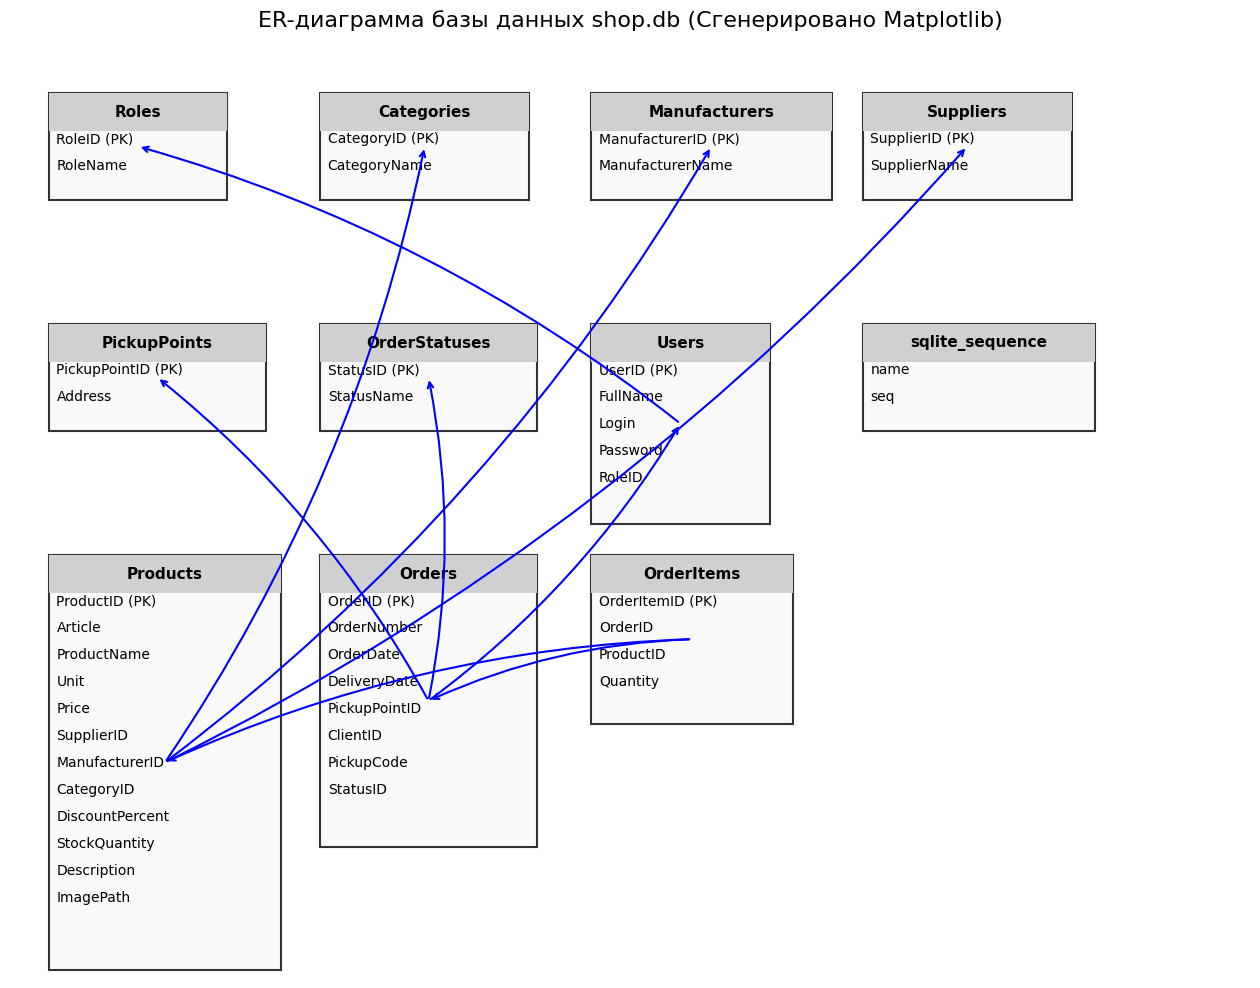

✅ Диаграмма успешно сгенерирована!
📁 Файл 'er_diagram_generated.png' сохранен в папке с проектом.


In [6]:
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def generate_er_png():
    conn = sqlite3.connect('shop.db')
    cursor = conn.cursor()

    # 1. Получаем список таблиц и их структуру
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
    tables = [row[0] for row in cursor.fetchall()]

    table_data = {}
    foreign_keys = []

    for table in tables:
        # Информация о столбцах
        cursor.execute(f"PRAGMA table_info({table})")
        cols = cursor.fetchall()
        pks = [c[1] for c in cols if c[5] > 0]
        table_data[table] = {'cols': cols, 'pks': pks}

        # Информация о внешних ключах
        cursor.execute(f"PRAGMA foreign_key_list({table})")
        for fk in cursor.fetchall():
            # fk[3] - откуда, fk[2] - куда таблица, fk[4] - куда колонка
            foreign_keys.append((table, fk[3], fk[2], fk[4]))

    # 2. Настройка холста для рисования
    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_xlim(0, 16)
    ax.set_ylim(12, 0)  # Инвертируем ось Y, чтобы рисовать сверху вниз
    ax.axis('off')

    # 3. Расставляем таблицы по сетке
    cols_grid = 4
    col_width = 3.5
    row_height = 3.0
    table_positions = {}

    for i, table in enumerate(tables):
        row = i // cols_grid
        col = i % cols_grid

        x = col * col_width + 0.5
        y = row * row_height + 0.5

        # Рассчитываем ширину исходя из самого длинного названия столбца
        max_len = max([len(table)] + [len(c[1]) for c in table_data[table]['cols']])
        width = max_len * 0.1 + 1.5
        height = len(table_data[table]['cols']) * 0.4 + 0.6

        table_positions[table] = {'x': x, 'y': y, 'w': width, 'h': height}

        # Рисуем рамку таблицы
        rect = patches.Rectangle((x, y), width, height, linewidth=1.5, 
                                 edgecolor='#333333', facecolor='#f9f9f9')
        ax.add_patch(rect)

        # Рисуем заголовок (имя таблицы) с затемненным фоном
        header_rect = patches.Rectangle((x, y), width, 0.5, linewidth=0, facecolor='#d0d0d0')
        ax.add_patch(header_rect)
        ax.text(x + width/2, y + 0.25, table, ha='center', va='center', 
                weight='bold', fontsize=11, color='black')

        # Рисуем строки столбцов
        for idx, col_info in enumerate(table_data[table]['cols']):
            col_name = col_info[1]
            if col_name in table_data[table]['pks']:
                col_name += " (PK)"  # Помечаем первичный ключ
            ax.text(x + 0.1, y + 0.6 + (idx * 0.35), col_name, ha='left', va='center', fontsize=10)

    # 4. Рисуем связи между таблицами (Foreign Keys)
    for fk in foreign_keys:
        from_table, from_col, to_table, to_col = fk

        if from_table in table_positions and to_table in table_positions:
            p1 = table_positions[from_table]
            p2 = table_positions[to_table]

            # Координаты центров таблиц
            x1, y1 = p1['x'] + p1['w']/2, p1['y'] + p1['h']/2
            x2, y2 = p2['x'] + p2['w']/2, p2['y'] + p2['h']/2

            # Рисуем стрелочку связи (от дочерней к родительской)
            ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                         arrowprops=dict(arrowstyle="->", color='blue', lw=1.5, 
                                         connectionstyle="arc3,rad=.1"))

    plt.title("ER-диаграмма базы данных shop.db (Сгенерировано Matplotlib)", fontsize=16, pad=20)

    # 5. Сохраняем и показываем
    plt.savefig('er_diagram_generated.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Диаграмма успешно сгенерирована!")
    print("📁 Файл 'er_diagram_generated.png' сохранен в папке с проектом.")

if __name__ == "__main__":
    generate_er_png()